/tmp/ipykernel_166843/239418510.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


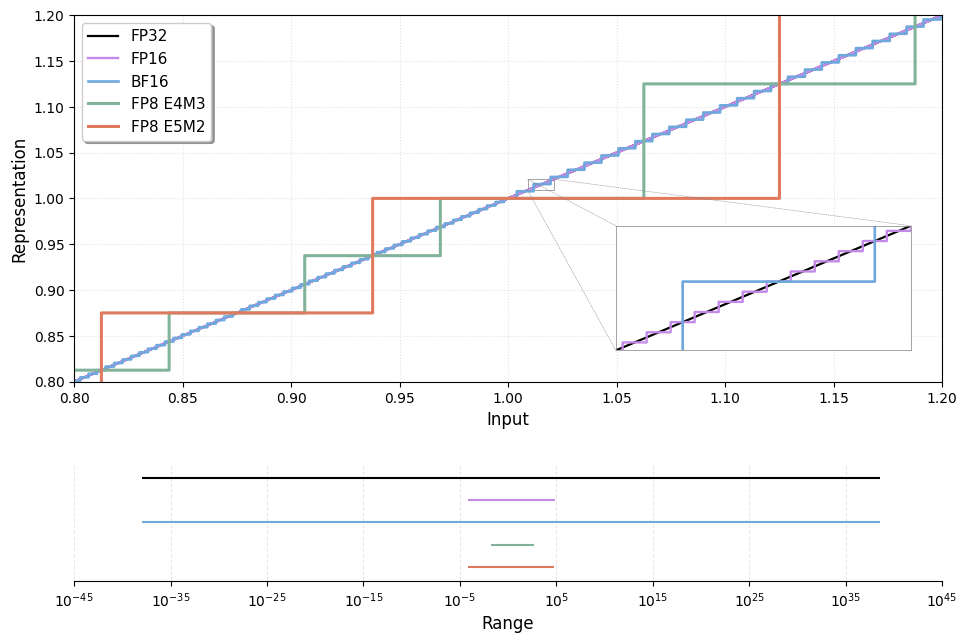

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def float_quantize(x, mant_bits):
    x = np.asarray(x, dtype=float)
    safe_x = np.where(x == 0, 1e-30, x)
    exponent = np.floor(np.log2(np.abs(safe_x)))
    ulp = 2.0 ** (exponent - mant_bits)
    return np.round(x / ulp) * ulp

formats = [
    {
        "name": "FP32",
        "mant": 23,
        "min": 1.2e-38,
        "max": 3.4e38,
        "color": "#000000",   # black
        "lw": 1.6
    },
    {
        "name": "FP16",
        "mant": 10,
        "min": 6.1e-5,
        "max": 6.5e4,
        "color": "#C48AE7",   # light pastel blue
        "lw": 1.7
    },
    {
        "name": "BF16",
        "mant": 7,
        "min": 1.2e-38,
        "max": 3.4e38,
        "color": "#6EA8DC",   # medium muted blue
        "lw": 1.9
    },
    {
        "name": "FP8 E4M3",
        "mant": 3,
        "min": 2**-6,
        "max": 448.0,
        "color": "#81B29A",   # same muted green as ablation
        "lw": 2.2
    },
    {
        "name": "FP8 E5M2",
        "mant": 2,
        "min": 2**-14,
        "max": 57344.0,
        "color": "#E07A5F",   # same muted coral as ablation
        "lw": 2.2
    },
]
smaller = 0.7
fig = plt.figure(figsize=(16*smaller, 10.5*smaller))
gs = gridspec.GridSpec(2, 1, height_ratios=[2.25, 0.72], hspace=0.34)

# ---------------------------------------------------------------------
# Top plot
# ---------------------------------------------------------------------

ax1 = plt.subplot(gs[0])
x_zoom = np.linspace(0.8, 1.2, 5000)

# ax1.plot(
#     x_zoom,
#     x_zoom,
#     color="black",
#     alpha=0.18,
#     linestyle="--",
#     lw=1.4,
#     label="Ideal"
# )

for fmt in formats:
    y_quant = float_quantize(x_zoom, fmt["mant"])
    ax1.step(
        x_zoom,
        y_quant,
        where="post",
        color=fmt["color"],
        lw=fmt["lw"],
        label=fmt["name"]
    )

# ax1.set_title(
#     "Precision",
#     fontsize=16,
#     # fontweight="bold",
#     pad=16
# )
ax1.set_xlabel("Input", fontsize=12)
ax1.set_ylabel("Representation", fontsize=12)
ax1.set_xlim(0.8, 1.2)
ax1.set_ylim(0.8, 1.2)
ax1.grid(True, linestyle=":", alpha=0.35)
ax1.legend(loc="upper left", frameon=True, shadow=True, fontsize=11)


# ---------------------------------------------------------------------
# Inset magnifier
# ---------------------------------------------------------------------

x1, x2 = 0.9940+.015, 1.0060+.015
y1, y2 =  0.9940+.015, 1.0060+.015
x_inset = np.linspace(x1, x2, 15000)

# Draw zoom rectangle on main axis
zoom_rect = Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    fill=False,
    edgecolor="0.5",   # grey
    linewidth=0.5,     # thinner
    linestyle="-"
)
ax1.add_patch(zoom_rect)

# Place inset with more breathing room from border
axins = inset_axes(
    ax1,
    width="34%",
    height="34%",
    loc="lower right",
    borderpad=2.25,
)

for fmt in formats[:3]:
    y_inset = float_quantize(x_inset, fmt["mant"])
    axins.step(
        x_inset,
        y_inset,
        where="post",
        color=fmt["color"],
        lw=fmt["lw"]
    )

axins.plot(x_inset, x_inset, color="black", alpha=0.22, linestyle=":", lw=0.5)

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
# axins.grid(True, linestyle=":", alpha=0.30)
# axins.set_title("Magnifier: FP32 vs FP16 vs BF16", fontsize=10, pad=6)
# axins.tick_params(labelsize=8)

# axins.set_xticks([1.000, 1.004, 1.008, 1.012])
# axins.set_yticks([1.000, 1.004, 1.008, 1.012])

# axins.text(
#     0.03,
#     0.06,
#     "ULP near 1:\nFP32 ≈ $2^{-23}$\nFP16 ≈ $2^{-10}$\nBF16 ≈ $2^{-7}$",
#     transform=axins.transAxes,
#     fontsize=8,
#     va="bottom",
#     ha="left",
#     bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=2)
# )

for spine in axins.spines.values():
    spine.set_linewidth(0.5)
    spine.set_edgecolor("0.5")

# Better magnifier connectors:
# Connect all four rectangle corners to inset corners, so the zoom relation is obvious.
connector_style = dict(
    color="0.5",       # grey
    linewidth=0.5,
    alpha=0.8,
    linestyle=":"
)

corners_main = [
    (x1, y1),
    # (x2, y1),
    (x1, y2),
    (x2, y2),
]

corners_inset = [
    (0, 0),
    # (1, 0),
    (0, 1),
    (1, 1),
]

for xy_main, xy_inset in zip(corners_main, corners_inset):
    con = ConnectionPatch(
        xyA=xy_inset,
        coordsA=axins.transAxes,
        xyB=xy_main,
        coordsB=ax1.transData,
        **connector_style
    )
    fig.add_artist(con)


# ---------------------------------------------------------------------
# Bottom plot: dynamic range
# ---------------------------------------------------------------------

ax2 = plt.subplot(gs[1])

# More compact spacing
y_positions = np.arange(len(formats))[::-1] * 0.55

for y_pos, fmt in zip(y_positions, formats):
    ax2.hlines(
        y_pos,
        fmt["min"],
        fmt["max"],
        color=fmt["color"],
        lw=1.5,
        capstyle="butt"
    )
    # ax2.text(
    #     2.5e-48,
    #     y_pos,
    #     fmt["name"],
    #     va="center",
    #     ha="right",
    #     fontweight="bold",
    #     fontsize=10,
    #     color=fmt["color"]
    # )

ax2.set_xscale("log")
ax2.set_xlim(1e-45, 1e45)
ax2.set_ylim(-0.35, y_positions.max() + 0.35)
ax2.set_yticks([])

# ax2.set_title(
#     "Range",
#     fontsize=16,
#     # fontweight="bold",
#     pad=5
# )
ax2.set_xlabel("Range", fontsize=12)

ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.28)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()